# Local xAI Analysis — Wind Energy Agent (*Eólico*)

**Objective:** Explain individual predictions of `modelo_eolico.pkl` using local explainability methods.

**Model input features (11):**
- Meteorological: `temperature_2m`, `relativehumidity_2m`, `dewpoint_2m`, `windspeed_10m`, `windspeed_100m`, `winddirection_10m`, `winddirection_100m`, `windgusts_10m`
- Temporal: `hour`, `dayofweek`, `dayofyear`

**Methods:**

| Method | Purpose |
|--------|---------|
| LIME | Linear surrogate explanation per instance |
| SHAP | Shapley attribution per instance |
| Ceteris Paribus / ICE | Effect of one feature, all others fixed |
| Counterfactuals | Minimal change to shift the prediction |
| What-If Scenarios | Hypothetical feature manipulations |

Three instances analyzed: **low**, **medium**, **high** wind power production.

## Imports

In [ ]:
import subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Loading

In [3]:
ROOT           = Path('../')
DATA_RAW_PATH  = ROOT / 'data' / 'raw' / 'DatosEolicos.csv'
DATA_PROC_PATH = ROOT / 'data' / 'processed' / 'Features_Eolico.csv'
MODEL_PATH     = ROOT / 'models' / 'modelo_eolico.pkl'

df_raw  = pd.read_csv(DATA_RAW_PATH,  parse_dates=['Date'])
df_proc = pd.read_csv(DATA_PROC_PATH, parse_dates=['Date'])
df = (df_proc.merge(df_raw[['Date', 'Power']], on='Date', how='inner')
             .dropna().reset_index(drop=True))

FEATURES = [
    'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
    'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
    'winddirection_100m', 'windgusts_10m', 'hour', 'dayofweek', 'dayofyear'
]
X = df[FEATURES].values
y = df['Power'].values

date_min = df['Date'].min().date()
date_max = df['Date'].max().date()
print(f'Dataset: {len(df):,} rows | {len(FEATURES)} features')
print(f'Date range: {date_min} to {date_max}')
print(f'Power (kW) — min: {y.min():.1f}  mean: {y.mean():.1f}  max: {y.max():.1f}')
df[FEATURES + ['Power']].describe().round(2)

Dataset: 35,040 rows | 11 features
Date range: 2017-01-02 to 2020-12-31
Power (kW) — min: 0.0  mean: 40.5  max: 98.6


,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,hour,dayofweek,dayofyear,Power
count,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.0,35040.00,35040.00
mean,47.46,72.26,38.19,3.62,6.33,201.04,201.45,7.83,11.50,4.0,183.25,40.54
std,19.45,16.78,18.82,1.66,2.69,97.18,98.56,3.59,6.92,2.0,105.37,28.56
min,-14.40,18.00,-17.10,0.00,0.10,0.00,0.00,0.50,0.00,1.0,1.00,0.00
25%,32.00,60.00,23.90,2.42,4.41,126.00,126.00,5.10,5.75,2.0,92.00,15.17
50%,46.50,74.00,37.70,3.32,6.11,224.00,225.00,7.30,11.50,4.0,183.00,35.04
75%,63.90,86.00,54.30,4.62,8.04,276.00,277.00,10.10,17.25,6.0,274.25,65.66
max,94.10,100.00,76.30,13.45,20.65,359.00,359.00,28.50,23.00,7.0,366.00,98.57


---
## 2. Exploratory Data Analysis (EDA)

Before applying xAI methods we examine distributions, correlations, and outliers
to inform case selection and interpret local explanations.

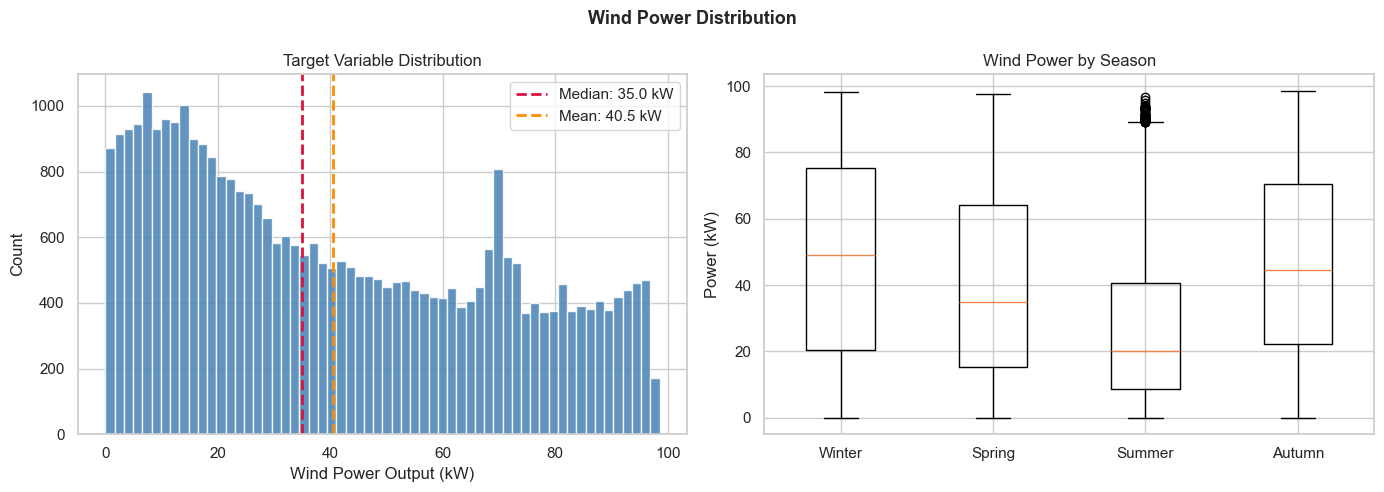

Near-zero output (<1 kW): 1.6%
Percentiles — P10: 6.3  P50: 35.0  P90: 83.8 kW


In [4]:
# ── Target distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(y), color='crimson', linestyle='--', linewidth=2,
                label=f'Median: {np.median(y):.1f} kW')
axes[0].axvline(np.mean(y), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(y):.1f} kW')
axes[0].set_xlabel('Wind Power Output (kW)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Variable Distribution')
axes[0].legend()

df_eda = df.copy()
df_eda['season'] = pd.cut(df_eda['dayofyear'], bins=[0, 79, 172, 265, 366],
                           labels=['Winter', 'Spring', 'Summer', 'Autumn'])
season_data = [df_eda.loc[df_eda['season'] == s, 'Power'].values
               for s in ['Winter', 'Spring', 'Summer', 'Autumn']]
axes[1].boxplot(season_data, labels=['Winter', 'Spring', 'Summer', 'Autumn'])
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Wind Power by Season')

plt.suptitle('Wind Power Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

pct_zero = (y < 1.0).mean() * 100
p10, p50, p90 = np.percentile(y, [10, 50, 90])
print(f'Near-zero output (<1 kW): {pct_zero:.1f}%')
print(f'Percentiles — P10: {p10:.1f}  P50: {p50:.1f}  P90: {p90:.1f} kW')

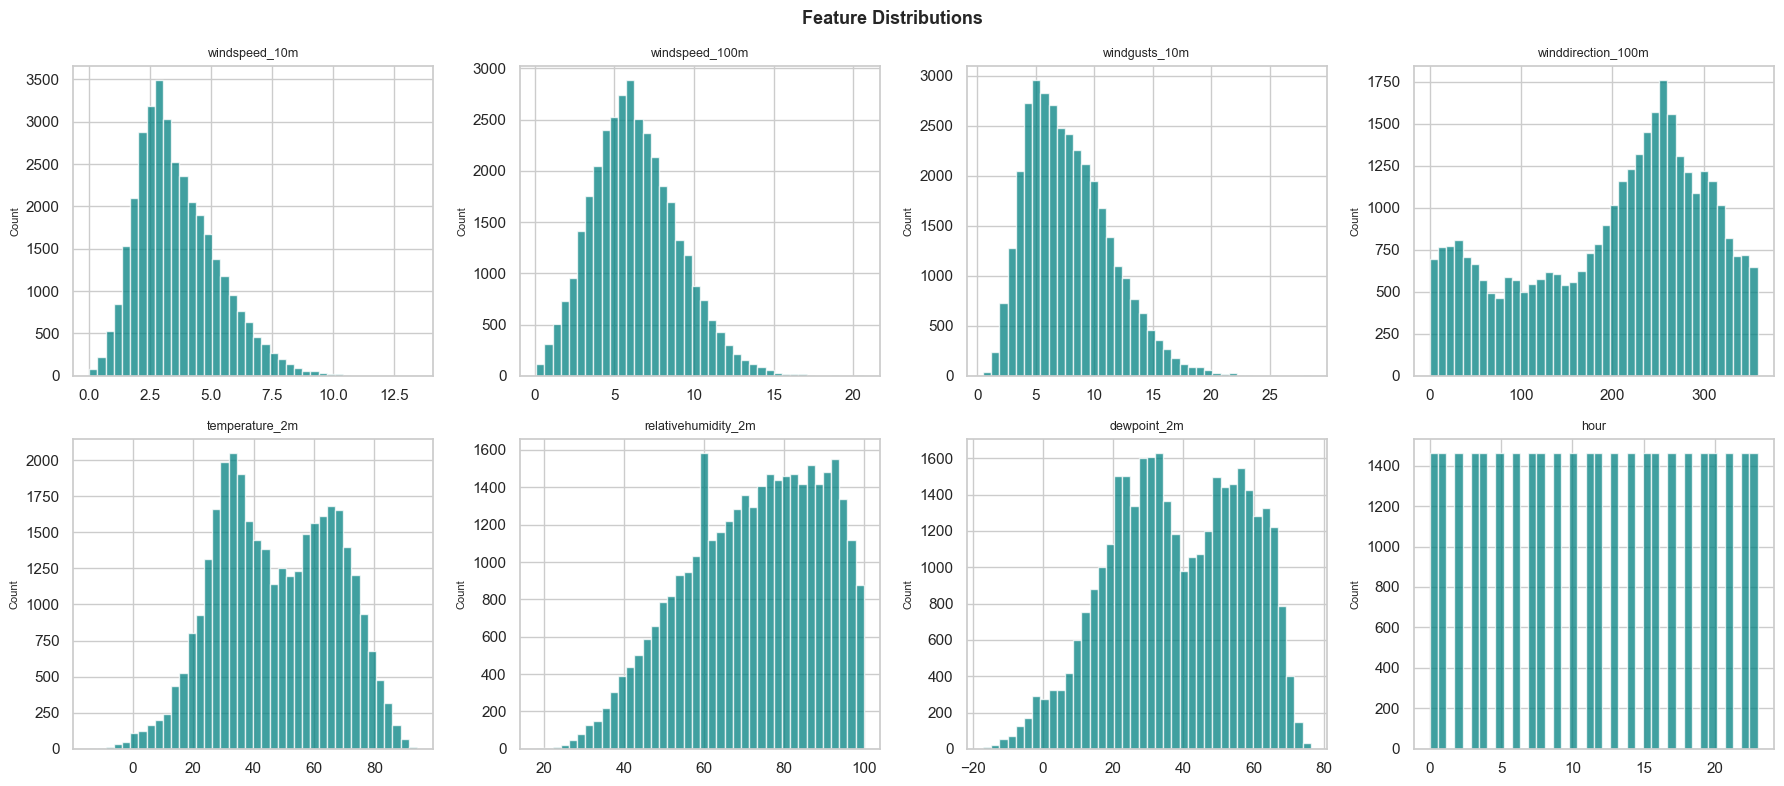

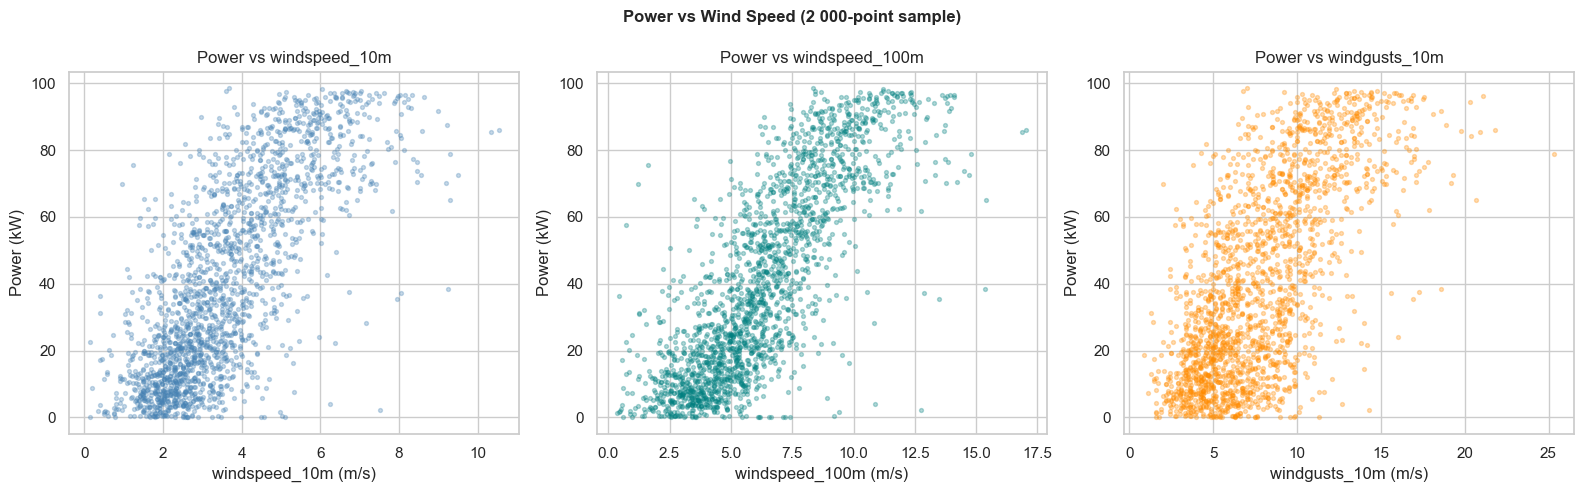

In [5]:
# ── Feature distributions ────────────────────────────────────────────────────
feats_to_plot = ['windspeed_10m', 'windspeed_100m', 'windgusts_10m', 'winddirection_100m',
                 'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'hour']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), feats_to_plot):
    ax.hist(df[feat], bins=40, color='teal', alpha=0.75, edgecolor='white')
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Count', fontsize=8)

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Power vs wind speed scatter ───────────────────────────────────────────────
sample_idx = np.random.choice(len(df), 2000, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat, clr in zip(axes,
                          ['windspeed_10m', 'windspeed_100m', 'windgusts_10m'],
                          ['steelblue', 'teal', 'darkorange']):
    ax.scatter(df[feat].iloc[sample_idx], y[sample_idx], alpha=0.3, s=8, color=clr)
    ax.set_xlabel(f'{feat} (m/s)')
    ax.set_ylabel('Power (kW)')
    ax.set_title(f'Power vs {feat}')

plt.suptitle('Power vs Wind Speed (2 000-point sample)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

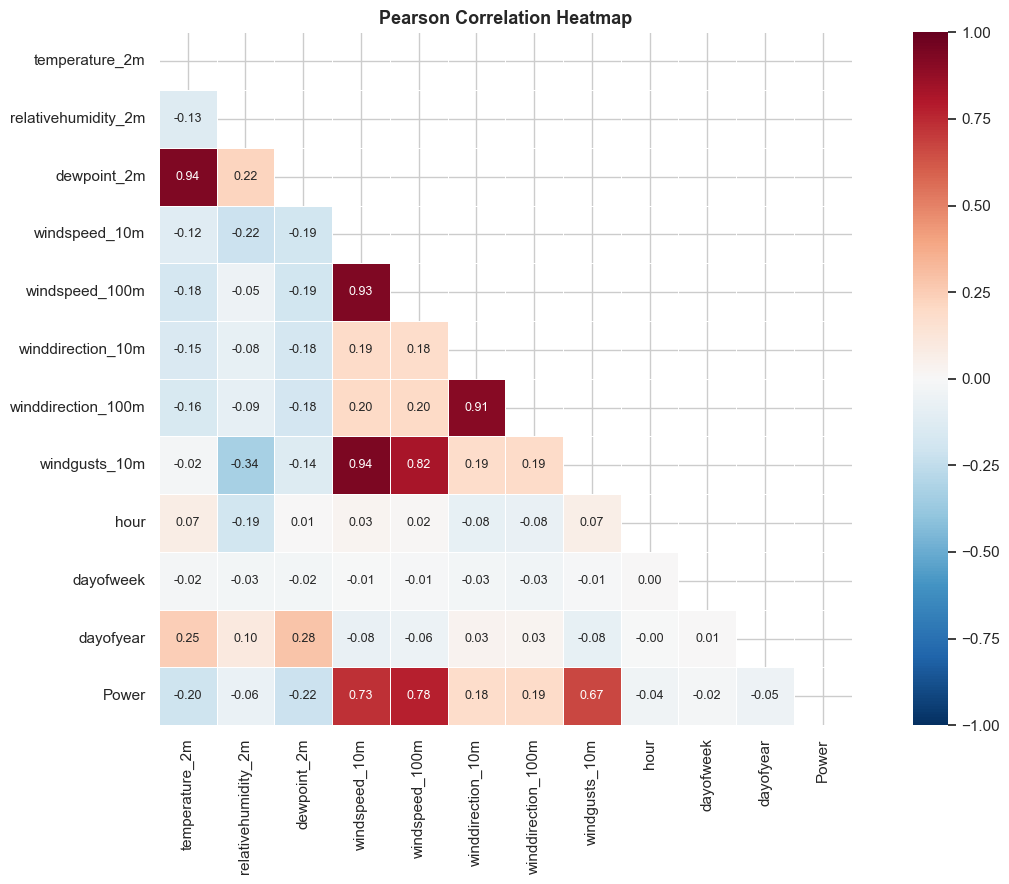

Top correlations with Power (|r|):
  windspeed_100m               0.777  #######################
  windspeed_10m                0.734  ######################
  windgusts_10m                0.665  ###################
  dewpoint_2m                  0.218  ######
  temperature_2m               0.205  ######
  winddirection_100m           0.192  #####
  winddirection_10m            0.180  #####
  relativehumidity_2m          0.064  #
  dayofyear                    0.052  #
  hour                         0.044  #
  dayofweek                    0.023  


In [6]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
corr = df[FEATURES + ['Power']].corr()
plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4, square=True, annot_kws={'size': 9})
plt.title('Pearson Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Top correlations with Power (|r|):')
corr_tgt = corr['Power'].drop('Power').abs().sort_values(ascending=False)
for feat, val in corr_tgt.items():
    print(f'  {feat:<28} {val:.3f}  {"#" * int(val * 30)}')

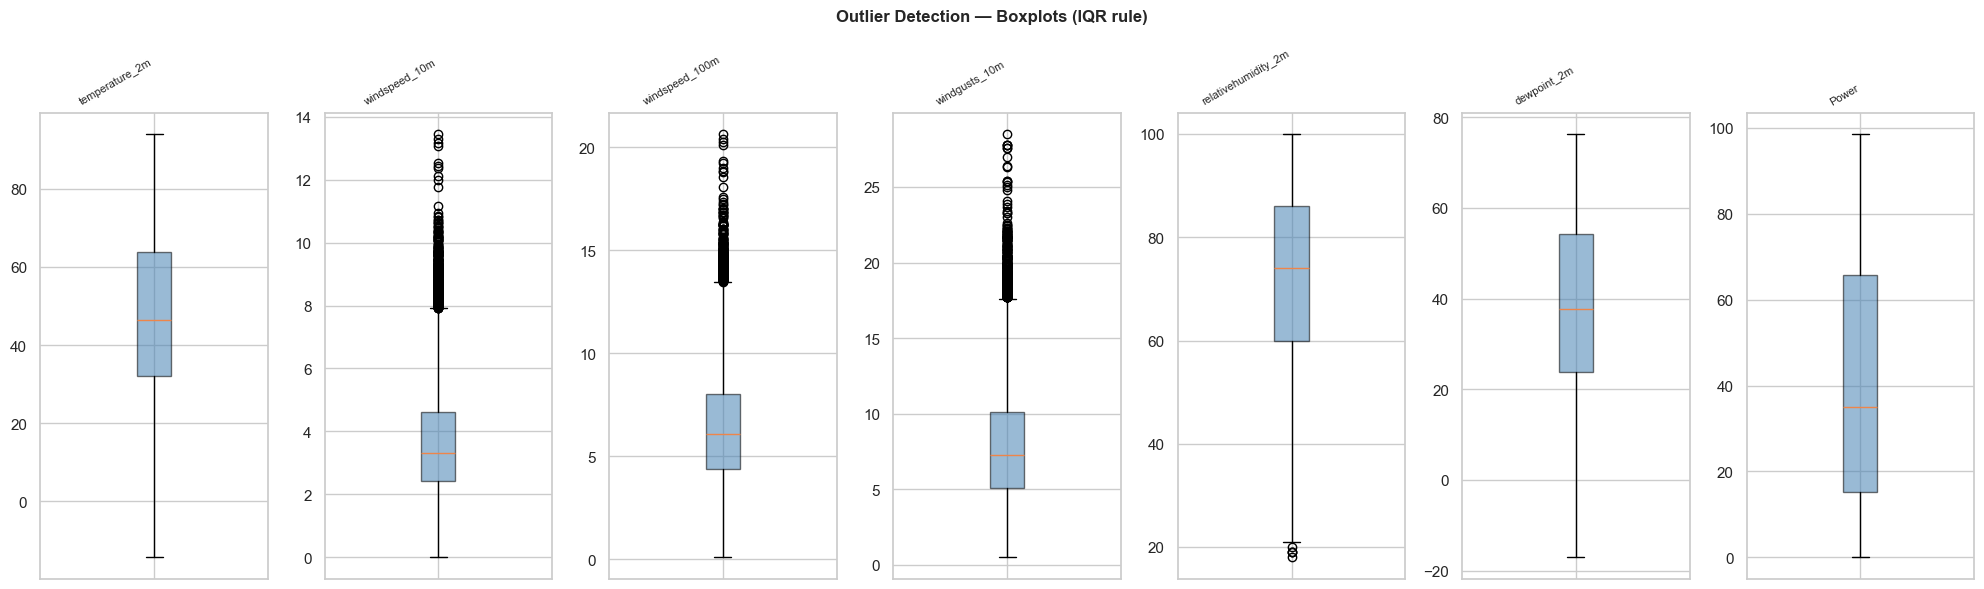

Outlier counts (1.5 × IQR rule):
  temperature_2m                  0  (0.0%)
  windspeed_10m                 501  (1.4%)
  windspeed_100m                332  (0.9%)
  windgusts_10m                 396  (1.1%)
  relativehumidity_2m             5  (0.0%)
  dewpoint_2m                     0  (0.0%)
  Power                           0  (0.0%)


In [7]:
# ── Outlier detection ────────────────────────────────────────────────────────
num_feats = ['temperature_2m', 'windspeed_10m', 'windspeed_100m',
             'windgusts_10m', 'relativehumidity_2m', 'dewpoint_2m', 'Power']

fig, axes = plt.subplots(1, len(num_feats), figsize=(20, 6))
for ax, feat in zip(axes, num_feats):
    vals = df[feat].values if feat != 'Power' else y
    ax.boxplot(vals, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.55))
    ax.set_title(feat, fontsize=8, rotation=30, ha='right')
    ax.set_xticklabels([])

plt.suptitle('Outlier Detection — Boxplots (IQR rule)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Outlier counts (1.5 × IQR rule):')
for feat in num_feats:
    vals = df[feat].values if feat != 'Power' else y
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    n_out = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()
    print(f'  {feat:<28} {n_out:4d}  ({n_out / len(vals) * 100:.1f}%)')

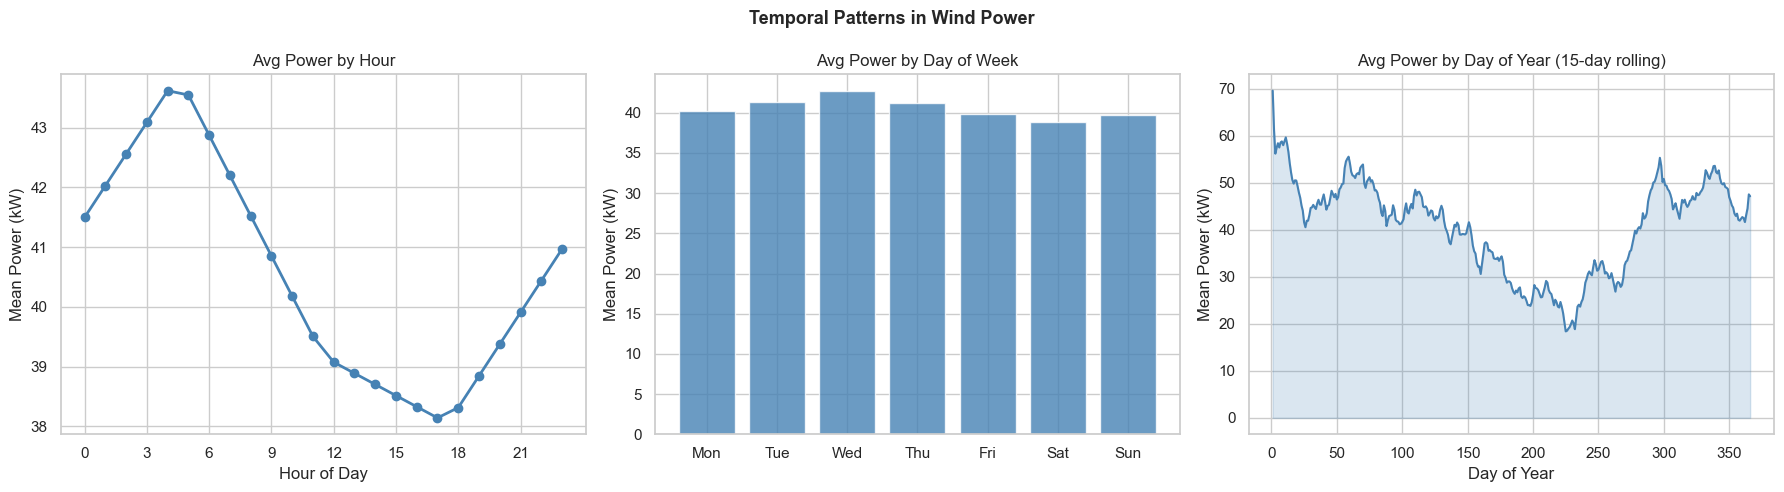

In [8]:
# ── Temporal patterns ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly = df.groupby('hour')['Power'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Mean Power (kW)')
axes[0].set_title('Avg Power by Hour'); axes[0].set_xticks(range(0, 24, 3))

dow = df.groupby('dayofweek')['Power'].mean()
axes[1].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], dow.values,
            color='steelblue', alpha=0.8)
axes[1].set_ylabel('Mean Power (kW)'); axes[1].set_title('Avg Power by Day of Week')

doy_avg = df.groupby('dayofyear')['Power'].mean().rolling(15, min_periods=1).mean()
axes[2].plot(doy_avg.index, doy_avg.values, color='steelblue', linewidth=1.5)
axes[2].fill_between(doy_avg.index, doy_avg.values, alpha=0.2, color='steelblue')
axes[2].set_xlabel('Day of Year'); axes[2].set_ylabel('Mean Power (kW)')
axes[2].set_title('Avg Power by Day of Year (15-day rolling)')

plt.suptitle('Temporal Patterns in Wind Power', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### EDA Key Insights

1. **Power is right-skewed** with a large near-zero mass. Turbines only produce above cut-in speed (~3 m/s).
2. **`windspeed_10m`, `windspeed_100m`, `windgusts_10m` are highly correlated** — LIME/SHAP may split importance arbitrarily among them.
3. **Strongest linear predictors**: wind speed variables dominate the correlation with Power.
4. **Circular features** (`winddirection`) have near-zero Pearson correlation; CP/ICE profiles reveal the real relationship.
5. **Temporal features** show modest signals; wind is mainly driven by synoptic meteorology, not time of day.
6. **Outliers** in wind speed are real storm events — local XAI on these cases is physically interesting.

---
## 3. Model Loading

In [9]:
print('Loading model — may take 30-60 s for a large ensemble...')
model = joblib.load(MODEL_PATH)

print(f'Model type: {type(model).__name__}')
if hasattr(model, 'named_steps'):
    print('Pipeline steps:', list(model.named_steps.keys()))
    final_est = list(model.named_steps.values())[-1]
    print(f'Final estimator: {type(final_est).__name__}')
if hasattr(model, 'feature_names_in_'):
    print('Feature names stored:', list(model.feature_names_in_))
else:
    print('Feature names (from ETL pipeline):', FEATURES)

sanity = model.predict(X[:5])
print()
print('Sanity check — first 5 predictions vs actuals:')
pd.DataFrame({'Predicted (kW)': sanity.round(2), 'Actual (kW)': y[:5].round(2)})

Loading model — may take 30-60 s for a large ensemble...
Model type: RandomForestRegressor
Feature names stored: ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 'winddirection_100m', 'windgusts_10m', 'hour', 'dayofweek', 'dayofyear']

Sanity check — first 5 predictions vs actuals:


,Predicted (kW),Actual (kW)
0,15.10,16.35
1,13.84,14.24
2,12.19,12.14
3,10.66,10.03
4,14.10,7.93


---
## 4. Case Selection

Three instances spanning the full range of wind power production:

| | Case | Rationale |
|--|------|-----------|
| **Case 1** | Low production (~P10) | Near cut-in speed, calm conditions |
| **Case 2** | Medium production (~P50) | Typical operating point |
| **Case 3** | High production (~P90) | Near rated power, strong wind |

In [10]:
print('Generating full-dataset predictions...')
preds_all = model.predict(X)
p10, p50, p90 = np.percentile(preds_all, [10, 50, 90])

idx_low    = int(np.argmin(np.abs(preds_all - p10)))
idx_medium = int(np.argmin(np.abs(preds_all - p50)))
idx_high   = int(np.argmin(np.abs(preds_all - p90)))

CASE_INDICES = [idx_low, idx_medium, idx_high]
CASE_LABELS  = ['Case 1 — Low', 'Case 2 — Medium', 'Case 3 — High']
CASE_COLORS  = ['#2196F3', '#FF9800', '#4CAF50']

rows = []
for label, idx in zip(CASE_LABELS, CASE_INDICES):
    row = df.iloc[idx]
    rows.append({
        'Case': label,
        'Date': str(row['Date'].date()),
        'Predicted (kW)': round(float(preds_all[idx]), 2),
        'Actual (kW)': round(float(y[idx]), 2),
        'windspeed_100m': round(float(row['windspeed_100m']), 2),
        'windgusts_10m': round(float(row['windgusts_10m']), 2),
        'hour': int(row['hour']),
        'dayofyear': int(row['dayofyear']),
    })

cases_df = pd.DataFrame(rows).set_index('Case')
print('Selected cases:')
cases_df

Generating full-dataset predictions...
Selected cases:


,Date,Predicted (kW),Actual (kW),windspeed_100m,windgusts_10m,hour,dayofyear
Case,,,,,,,
Case 1 — Low,2019-03-26,10.74,5.22,2.02,5.6,13,85
Case 2 — Medium,2017-06-27,34.94,31.33,5.42,7.5,19,178
Case 3 — High,2018-01-05,78.54,82.35,8.59,10.4,17,5


---
## 5. LIME — Local Interpretable Model-agnostic Explanations

LIME perturbs each instance, collects model predictions, and fits a weighted linear surrogate
in the local neighborhood. The surrogate's coefficients are the explanation.

**Reading LIME plots:**
- **Green** bars: feature pushes prediction **up** (more wind power)
- **Red** bars: feature pushes prediction **down** (less wind power)
- Feature conditions (e.g. `windspeed_100m > 5.2`) are LIME's local discretization

> **Note on multicollinearity:** `windspeed_10m`, `windspeed_100m`, and `windgusts_10m` are highly
> correlated. LIME may assign large weight to only one of them per run — a surrogate instability,
> not a model property. SHAP is more stable in this regard.

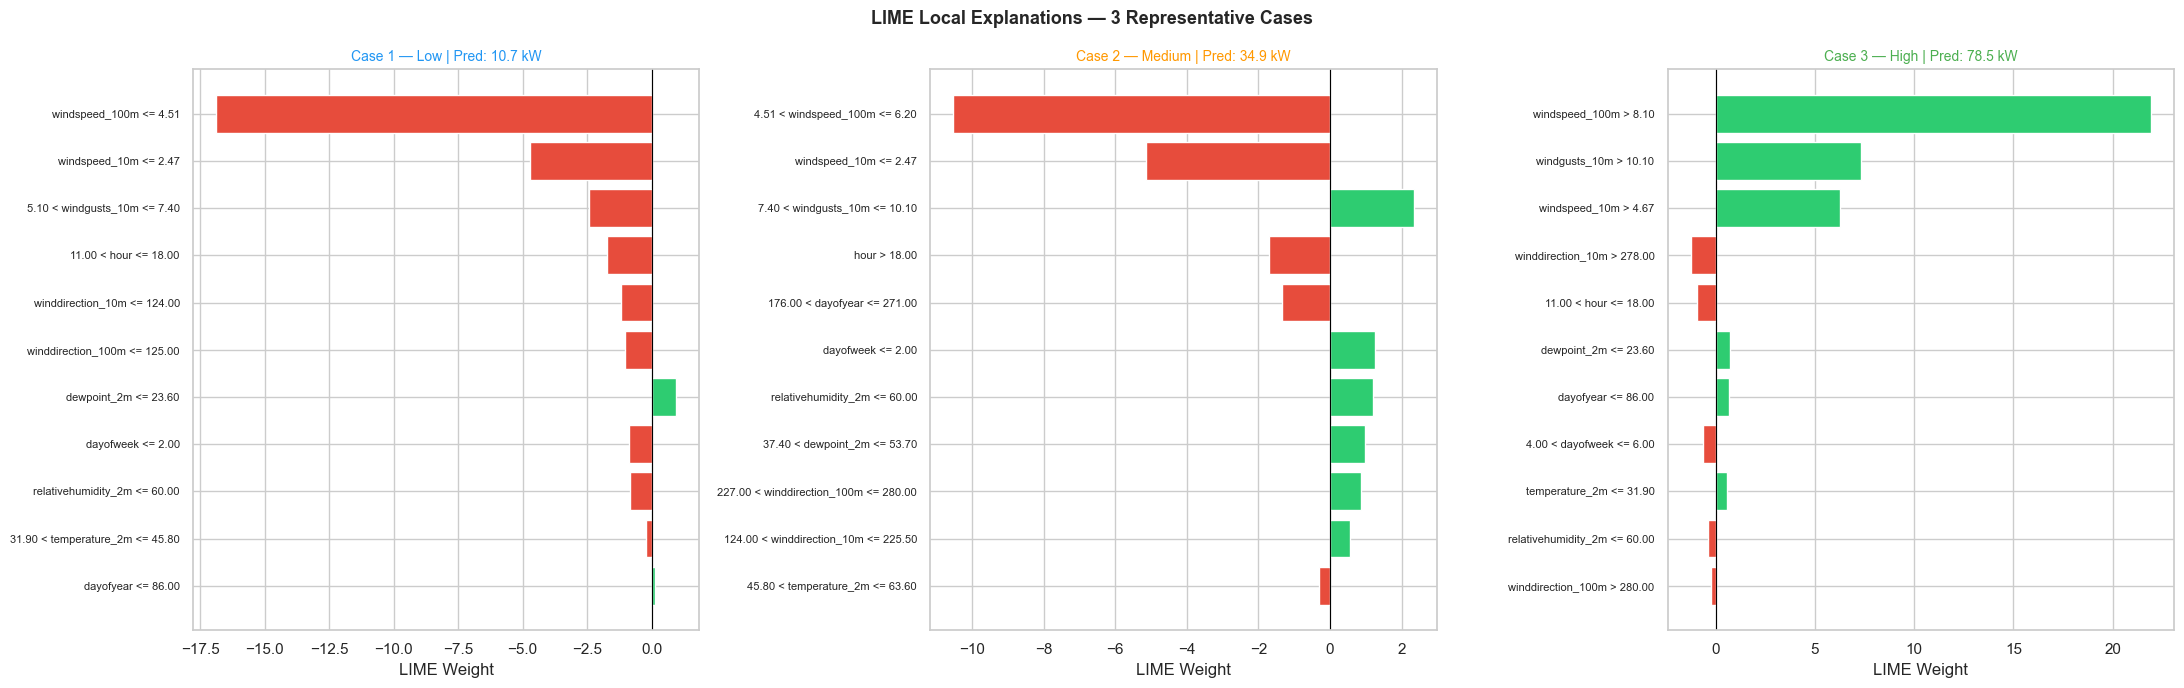

In [11]:
import lime
import lime.lime_tabular

bg_idx = np.random.choice(len(X), min(3000, len(X)), replace=False)
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X[bg_idx],
    feature_names=FEATURES,
    mode='regression',
    verbose=False,
    random_state=SEED
)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, case_idx, case_label, clr in zip(axes, CASE_INDICES, CASE_LABELS, CASE_COLORS):
    exp = lime_explainer.explain_instance(
        X[case_idx], model.predict,
        num_features=len(FEATURES), num_samples=1500
    )
    lime_list   = sorted(exp.as_list(), key=lambda t: abs(t[1]))
    feat_labels = [t[0] for t in lime_list]
    weights     = [t[1] for t in lime_list]
    bar_colors  = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]

    ax.barh(feat_labels, weights, color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    pred_val = preds_all[case_idx]
    ax.set_title(f'{case_label} | Pred: {pred_val:.1f} kW', fontsize=10, color=clr)
    ax.set_xlabel('LIME Weight')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('LIME Local Explanations — 3 Representative Cases', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. SHAP — SHapley Additive exPlanations

SHAP assigns each feature a Shapley value — its average marginal contribution across all feature
coalitions. Unlike LIME, SHAP satisfies **consistency** and **additivity**:
`f(x) = E[f(X)] + Σ SHAP_values`.

**Reading SHAP bar charts:**
- **Red / positive**: feature raises prediction above the base value
- **Blue / negative**: feature lowers prediction below the base value

**TreeExplainer** is used for tree-based models (fast, exact). KernelExplainer is the fallback.

Initializing SHAP explainer...
TreeExplainer failed. Falling back to KernelExplainer (slower)...


Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/3 [00:00<?, ?it/s]

KernelExplainer — base value E[f(X)] = 40.46 kW


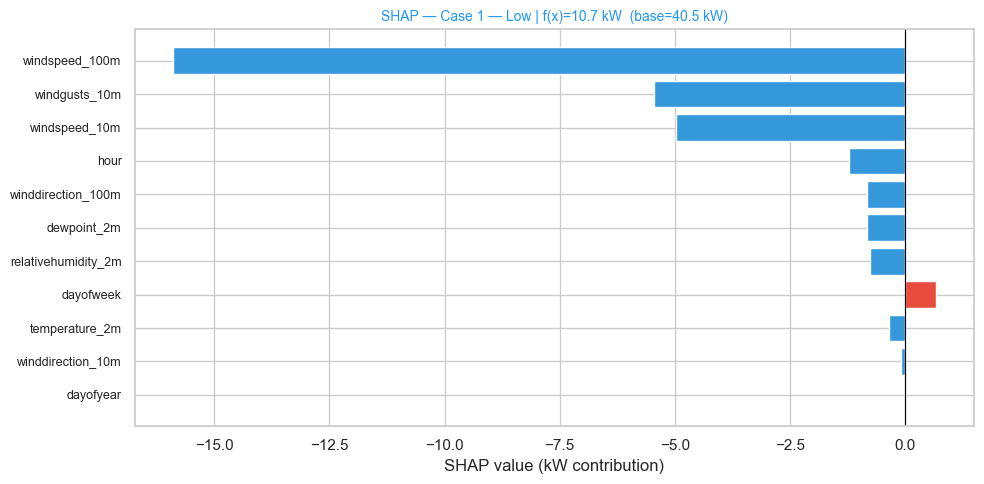

Case 1 — Low: base + sum(SHAP) = 40.46 + -29.73 = 10.74 | pred = 10.74 kW


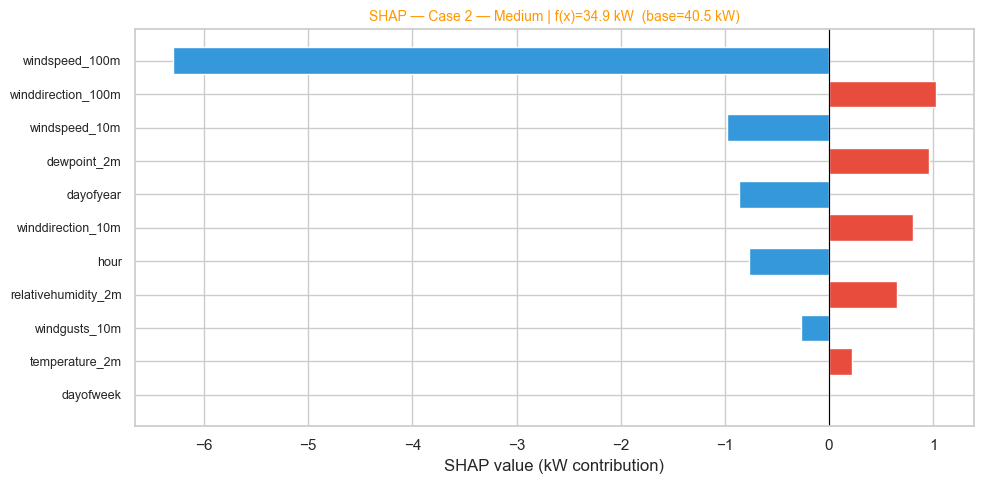

Case 2 — Medium: base + sum(SHAP) = 40.46 + -5.52 = 34.94 | pred = 34.94 kW


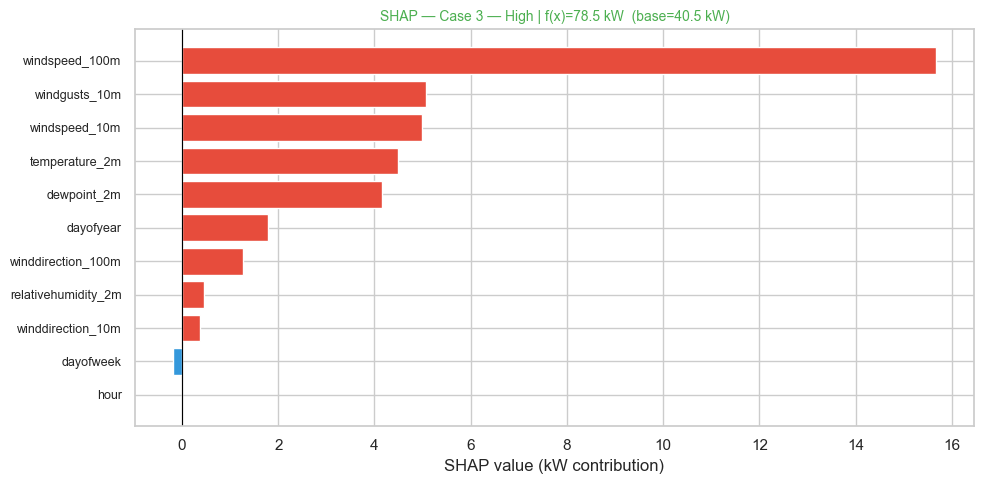

Case 3 — High: base + sum(SHAP) = 40.46 + 38.08 = 78.54 | pred = 78.54 kW


In [12]:
import shap

X_cases = X[CASE_INDICES]
print('Initializing SHAP explainer...')
try:
    shap_expl = shap.TreeExplainer(model)
    sv_cases  = shap_expl.shap_values(X_cases)
    ev        = float(shap_expl.expected_value)
    print(f'TreeExplainer OK — base value E[f(X)] = {ev:.2f} kW')
except Exception as e:
    print(f'TreeExplainer failed. Falling back to KernelExplainer (slower)...')
    bg_idx    = np.random.choice(len(X), 150, replace=False)
    shap_expl = shap.KernelExplainer(model.predict, X[bg_idx])
    sv_cases  = shap_expl.shap_values(X_cases, nsamples=300)
    ev        = float(shap_expl.expected_value)
    print(f'KernelExplainer — base value E[f(X)] = {ev:.2f} kW')

for i, (case_idx, case_label, clr) in enumerate(zip(CASE_INDICES, CASE_LABELS, CASE_COLORS)):
    sv   = sv_cases[i]
    pred = preds_all[case_idx]
    order      = np.argsort(np.abs(sv))
    sorted_sv  = sv[order]
    bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in sorted_sv]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([FEATURES[j] for j in order], sorted_sv, color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (kW contribution)')
    ax.set_title(f'SHAP — {case_label} | f(x)={pred:.1f} kW  (base={ev:.1f} kW)',
                 fontsize=10, color=clr)
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout(); plt.show()

    check = ev + sv.sum()
    print(f'{case_label}: base + sum(SHAP) = {ev:.2f} + {sv.sum():.2f} = {check:.2f} | pred = {pred:.2f} kW')

---
## 7. Ceteris Paribus / ICE Profiles

**ICE / Ceteris Paribus** profiles show how one specific instance's prediction changes as a single
feature varies across its range, all other features held fixed at their observed values.

- One curve per instance → truly **local** (contrast with PDP which averages over the population)
- Dotted vertical lines mark each case's actual observed feature value
- Filled dots mark the actual predictions

We profile the four most physically relevant features for wind power generation.

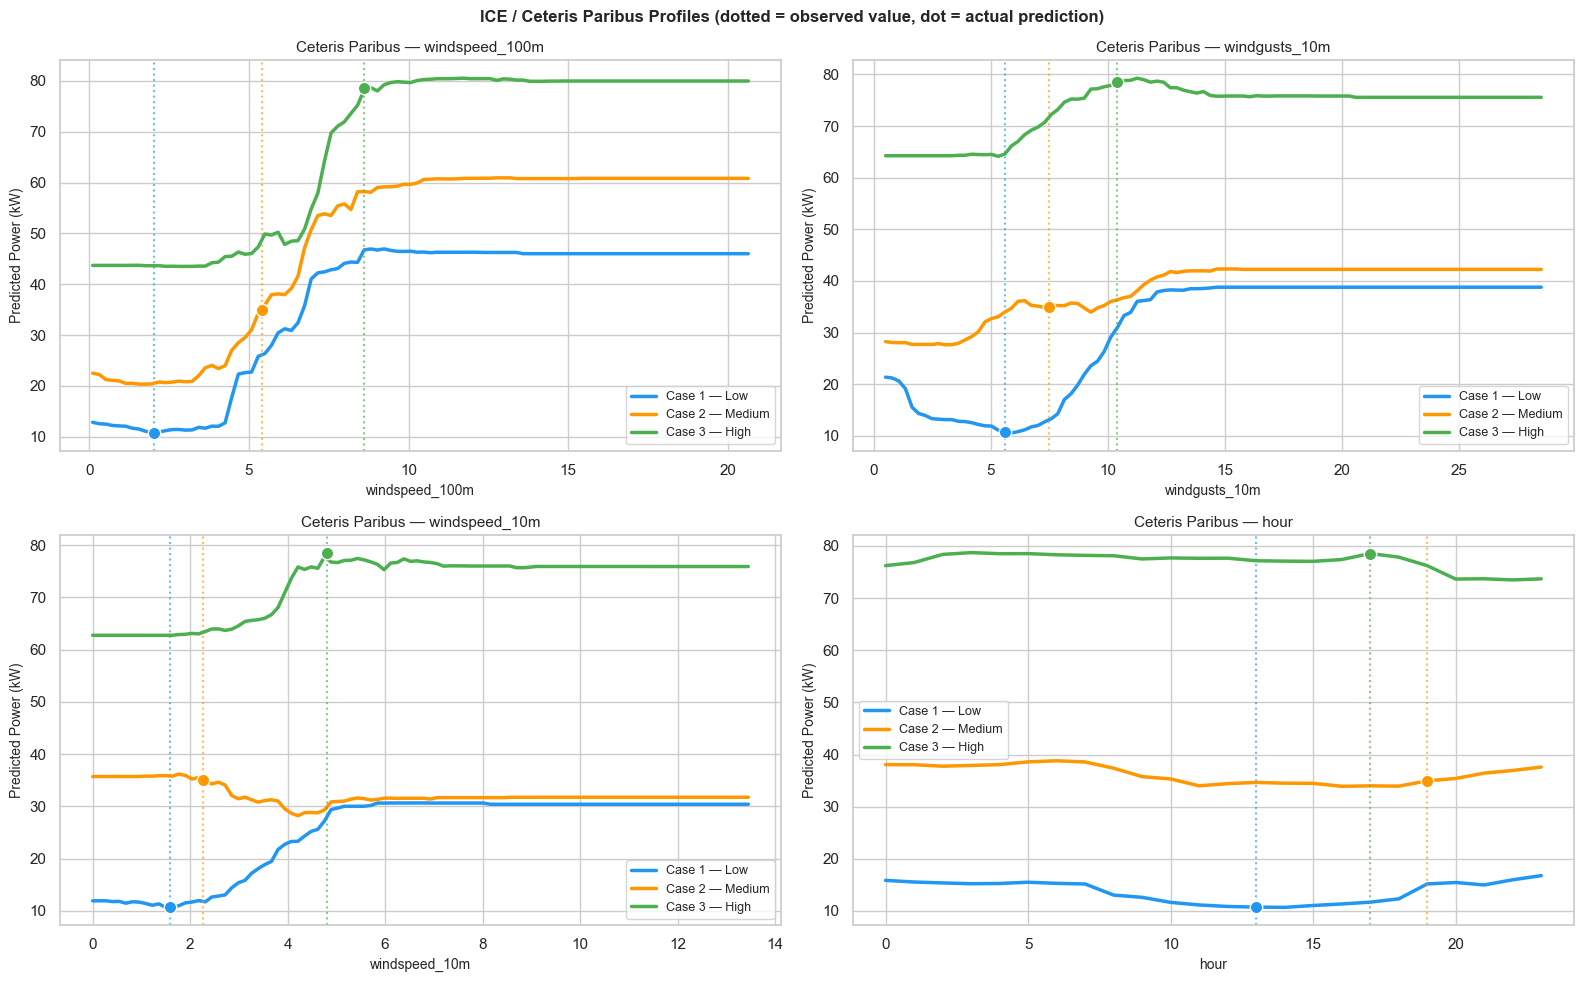

In [13]:
def ceteris_paribus(model, instance, feat_idx, feat_values):
    preds = []
    for v in feat_values:
        mod = instance.copy().astype(float)
        mod[feat_idx] = v
        preds.append(model.predict([mod])[0])
    return np.array(preds)

CP_CONFIG = {
    'windspeed_100m': np.linspace(df['windspeed_100m'].min(), df['windspeed_100m'].max(), 100),
    'windgusts_10m':  np.linspace(df['windgusts_10m'].min(),  df['windgusts_10m'].max(),  100),
    'windspeed_10m':  np.linspace(df['windspeed_10m'].min(),  df['windspeed_10m'].max(),  100),
    'hour':           np.arange(0, 24),
}
feat_idx_map = {f: FEATURES.index(f) for f in CP_CONFIG}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (feat_name, feat_vals) in zip(axes.flatten(), CP_CONFIG.items()):
    fi = feat_idx_map[feat_name]
    for case_idx, case_label, clr in zip(CASE_INDICES, CASE_LABELS, CASE_COLORS):
        profile = ceteris_paribus(model, X[case_idx], fi, feat_vals)
        ax.plot(feat_vals, profile, label=case_label, color=clr, linewidth=2.5)
        ax.axvline(X[case_idx][fi], color=clr, linestyle=':', alpha=0.65)
        ax.scatter([X[case_idx][fi]], [preds_all[case_idx]], color=clr, s=80, zorder=5, edgecolors='white')
    ax.set_xlabel(feat_name, fontsize=10)
    ax.set_ylabel('Predicted Power (kW)', fontsize=10)
    ax.set_title(f'Ceteris Paribus — {feat_name}', fontsize=11)
    ax.legend(fontsize=9, loc='best')

plt.suptitle('ICE / Ceteris Paribus Profiles (dotted = observed value, dot = actual prediction)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Counterfactual Explanations

A **counterfactual** is the minimal change to an instance's features that shifts the prediction
by at least **15 kW**. It answers: *"What would need to change to produce significantly more
(or less) power?"*

**Method:** Random-search over 1–3 feature perturbations within the observed data range (P2–P98).
Bar charts compare the original feature values to the counterfactual values.

In [ ]:
def find_counterfactual(model, instance, feat_names, df_ref,
                         target_delta=15, direction='more',
                         n_trials=10000, seed=42):
    rng = np.random.default_rng(seed)
    base_pred   = model.predict([instance])[0]
    feat_ranges = {f: (float(df_ref[f].quantile(0.02)), float(df_ref[f].quantile(0.98)))
                   for f in feat_names}
    best_cf, best_dist = None, np.inf
    for _ in range(n_trials):
        candidate = instance.copy().astype(float)
        for fi in rng.choice(len(feat_names), rng.integers(1, 4), replace=False):
            lo, hi = feat_ranges[feat_names[fi]]
            candidate[fi] = rng.uniform(lo, hi)
        cf_pred   = model.predict([candidate])[0]
        delta     = cf_pred - base_pred
        qualifies = ((direction == 'more' and delta >= target_delta) or
                     (direction == 'less' and delta <= -target_delta))
        if qualifies:
            dist = np.linalg.norm((candidate - instance) / (np.std(instance) + 1e-9))
            if dist < best_dist:
                best_dist = dist
                best_cf   = (candidate.copy(), cf_pred)
    return best_cf

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
for row_axes, case_idx, case_label, clr in zip(axes, CASE_INDICES, CASE_LABELS, CASE_COLORS):
    base_pred = preds_all[case_idx]
    for ax, direction in zip(row_axes, ['more', 'less']):
        result = find_counterfactual(model, X[case_idx], FEATURES, df,
                                      target_delta=15, direction=direction)
        title_str = f'{case_label} | Base: {base_pred:.1f} kW | Goal: {direction} power'
        ax.set_title(title_str, fontsize=9, color=clr)
        if result is None:
            ax.text(0.5, 0.5, 'No counterfactual found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11)
            ax.axis('off'); continue

        cf_inst, cf_pred = result
        delta   = cf_inst - X[case_idx]
        changed = [(FEATURES[i], float(X[case_idx][i]), float(cf_inst[i]))
                   for i in range(len(FEATURES)) if abs(delta[i]) > 0.1]
        if not changed:
            ax.text(0.5, 0.5, 'No significant change detected', ha='center', va='center',
                    transform=ax.transAxes); ax.axis('off'); continue

        feat_labels = [c[0] for c in changed]
        x_pos = np.arange(len(feat_labels)); w = 0.35
        ax.bar(x_pos - w/2, [c[1] for c in changed], w, label='Original', color=clr, alpha=0.7)
        ax.bar(x_pos + w/2, [c[2] for c in changed], w,
               label=f'CF ({cf_pred:.1f} kW)', color='gray', alpha=0.7)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(feat_labels, rotation=25, ha='right', fontsize=8)
        ax.set_ylabel('Feature value'); ax.legend(fontsize=8)

plt.suptitle('Counterfactual Explanations — Changed Features per Case',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 9. What-If Scenario Analysis

What-if analysis applies deliberate, physically motivated changes to an instance and observes how
the prediction responds. Unlike Ceteris Paribus, **multiple features change simultaneously**
to simulate realistic operational scenarios.

| Scenario | Features Changed | Physical Motivation |
|----------|-----------------|---------------------|
| **S1 — High Wind** | All wind speeds × 1.8 | Storm front: ~80% increase in wind |
| **S2 — Nighttime** | `hour = 2` | Diurnal wind shift: does time of day matter? |
| **S3 — Storm + Cold** | High gusts (P95) + low temp (P5) + 95% humidity | Adverse weather |
| **S4 — Calm** | All wind speeds × 0.3 | Near-calm: turbine approaching cut-in threshold |

In [ ]:
def apply_scenario(instance, feat_names, changes):
    modified = instance.copy().astype(float)
    for feat, new_val in changes.items():
        fi = feat_names.index(feat)
        modified[fi] = new_val(modified[fi]) if callable(new_val) else float(new_val)
    return modified

p95_gusts = float(df['windgusts_10m'].quantile(0.95))
p05_temp  = float(df['temperature_2m'].quantile(0.05))

SCENARIOS = {
    'Base': {},
    'S1 — High Wind': {
        'windspeed_10m':  lambda v: v * 1.8,
        'windspeed_100m': lambda v: v * 1.8,
        'windgusts_10m':  lambda v: v * 1.8,
    },
    'S2 — Night (h=2)': {'hour': 2},
    'S3 — Storm+Cold': {
        'windgusts_10m':       p95_gusts,
        'temperature_2m':      p05_temp,
        'relativehumidity_2m': 95.0,
    },
    'S4 — Calm': {
        'windspeed_10m':  lambda v: v * 0.3,
        'windspeed_100m': lambda v: v * 0.3,
        'windgusts_10m':  lambda v: v * 0.3,
    },
}

results = {}
for case_idx, case_label in zip(CASE_INDICES, CASE_LABELS):
    row = {}
    for sc_name, changes in SCENARIOS.items():
        inst = apply_scenario(X[case_idx], FEATURES, changes) if changes else X[case_idx]
        row[sc_name] = round(float(model.predict([inst])[0]), 2)
    results[case_label] = row

results_df = pd.DataFrame(results).T
print('What-If Scenario Results (predicted kW):')
results_df

In [ ]:
sc_names   = list(SCENARIOS.keys())
short_lbls = ['Base', 'S1: High Wind', 'S2: Night', 'S3: Storm', 'S4: Calm']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (case_label, clr) in zip(axes, zip(CASE_LABELS, CASE_COLORS)):
    vals     = results_df.loc[case_label, sc_names].values.astype(float)
    base_val = vals[0]
    bars = ax.bar(range(len(sc_names)), vals,
                  color=[clr] + ['#90A4AE'] * (len(vals) - 1), alpha=0.85, edgecolor='white')
    ax.axhline(base_val, color='black', linestyle='--', linewidth=1.2,
               label=f'Base: {base_val:.1f} kW')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + vals.max() * 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(sc_names)))
    ax.set_xticklabels(short_lbls, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Predicted Power (kW)')
    ax.set_title(case_label, fontsize=11, color=clr)
    ax.legend(fontsize=9)

plt.suptitle('What-If Scenario Impact on Predicted Wind Power', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Delta vs base (kW):')
results_df.subtract(results_df['Base'], axis=0).drop(columns=['Base']).round(2)

---
## 10. Conclusions

### Local Explanations Summary

| Method | Key Finding |
|--------|------------|
| **LIME** | Wind speed at 100m and gusts dominate in all three cases. Their absence (Case 1) or presence (Case 3) is the primary local explanation. |
| **SHAP** | Shapley values confirm additive feature contributions. The base value `E[f(X)]` is substantially below the maximum output, reflecting wind intermittency. |
| **Ceteris Paribus** | The power-curve shape (slow growth → steep rise → plateau) is clearly visible in `windspeed_100m` profiles. Case 3 is on the plateau — further wind increases yield diminishing returns. |
| **Counterfactuals** | Increasing wind speed variables is the most efficient lever. Temperature and humidity changes alone rarely shift the prediction by 15 kW. |
| **What-If** | S1 (High Wind) has large gains for Cases 1–2 but near-zero for Case 3 (saturation). S4 (Calm) dramatically reduces all predictions. S2 (Night) shows `hour` has limited local influence, consistent with the EDA finding. |

### Limitations
- **Multicollinearity**: LIME may arbitrarily assign importance to one wind speed feature per run. SHAP is more stable.
- **Circular features**: Wind direction is treated as a linear value — CP profiles for direction are ordinal, not circular.
- **Counterfactual completeness**: Random search finds *a* valid counterfactual, not necessarily the globally closest one. `pip install dice-ml` enables principled diverse counterfactuals.
- **Model scope**: All explanations reflect what the *model* learned, not the true physical process. Model biases propagate into XAI explanations.